## GPR on WeatherBench Data - z500
Apply GP regression baseline (using exact GP to train on monthly data)

In [1]:
%load_ext autoreload
%autoreload 2

# Check GPU
!nvidia-smi

Sun Apr 20 19:17:46 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.12             Driver Version: 535.104.12   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100 80GB PCIe          Off | 00000000:17:00.0 Off |                    0 |
| N/A   33C    P0              54W / 300W |      4MiB / 81920MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import time
import gc
from tqdm.notebook import tqdm

import torch
from torch.utils.data import TensorDataset, DataLoader
import gpytorch

from GPyTorch.GPRs.model import ExactGP
from GPyTorch.GPRs.kernel import SphericalMaternKernel
from GPyTorch.GPRs.process_data import create_latlon_data

torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Data Processing

Loading the data

In [ ]:
z500 = xr.open_mfdataset('data/5.625deg/geopotential_500/*.nc', combine='by_coords')
z500_train = z500.sel(time=slice('2017.12', '2017.12')).isel(lat=slice(0, 13), lon=slice(0, 22))['z']
z500_test = z500.sel(time=slice('2018', '2018.1.7')).isel(lat=slice(0, 13), lon=slice(0, 22))['z'] 

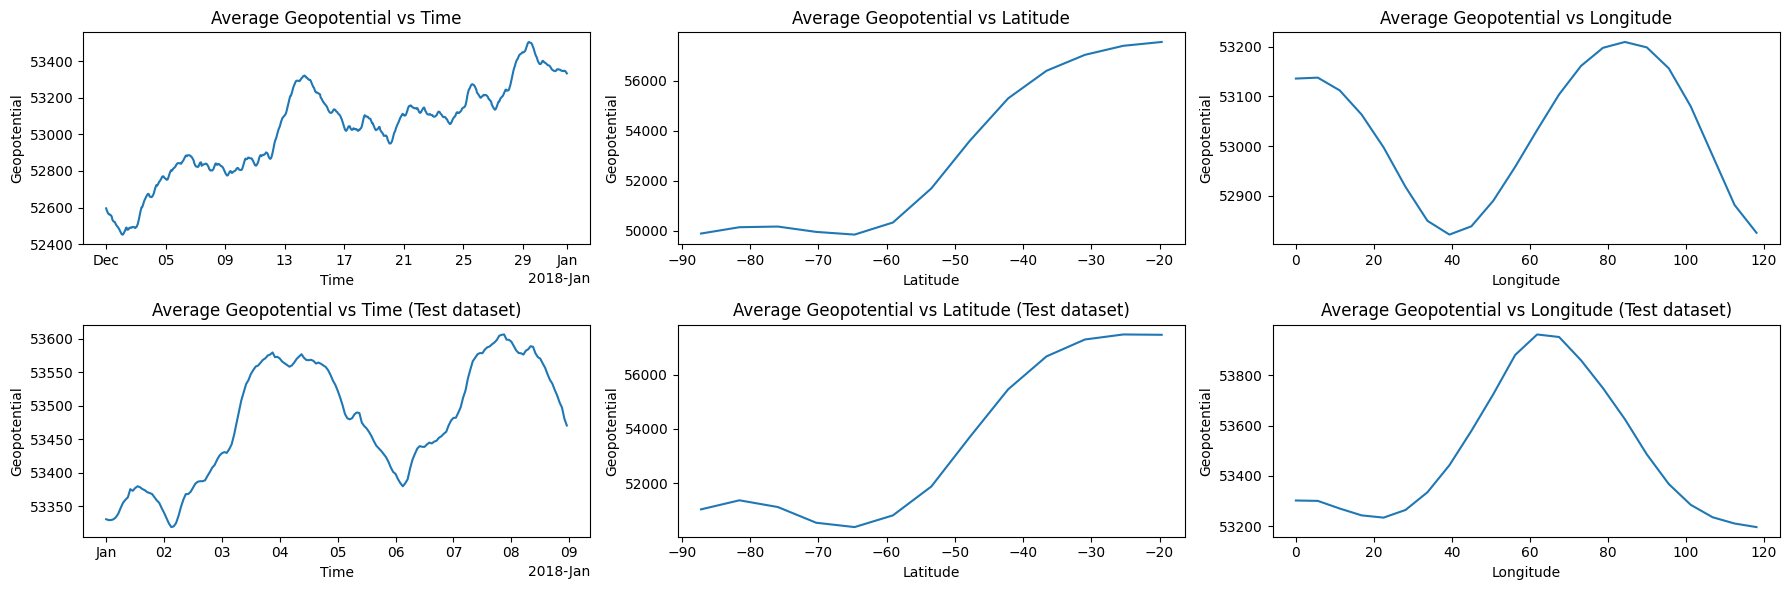

In [4]:
avg_time = z500_train.mean(dim=["lat", "lon"])
avg_lat = z500_train.mean(dim=["time", "lon"])
avg_lon = z500_train.mean(dim=["time", "lat"])

test_time = z500_test.mean(dim=["lat", "lon"])
test_lat = z500_test.mean(dim=["time", "lon"])
test_lon = z500_test.mean(dim=["time", "lat"])

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 6))
axs = axs.flatten()

avg_time.plot(ax=axs[0])
axs[0].set_title("Average Geopotential vs Time")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Geopotential")

avg_lat.plot(ax=axs[1])
axs[1].set_title("Average Geopotential vs Latitude")
axs[1].set_xlabel("Latitude")
axs[1].set_ylabel("Geopotential")

avg_lon.plot(ax=axs[2])
axs[2].set_title("Average Geopotential vs Longitude")
axs[2].set_xlabel("Longitude")
axs[2].set_ylabel("Geopotential")

test_time.plot(ax=axs[3])
axs[3].set_title("Average Geopotential vs Time (Test dataset)")
axs[3].set_xlabel("Time")
axs[3].set_ylabel("Geopotential")

test_lat.plot(ax=axs[4])
axs[4].set_title("Average Geopotential vs Latitude (Test dataset)")
axs[4].set_xlabel("Latitude")
axs[4].set_ylabel("Geopotential")

test_lon.plot(ax=axs[5])
axs[5].set_title("Average Geopotential vs Longitude (Test dataset)")
axs[5].set_xlabel("Longitude")
axs[5].set_ylabel("Geopotential")

fig.tight_layout()
fig.show()

In [5]:
data_mean = z500_train.mean().load()
data_std = z500_train.std().load()

# Normalize datasets
data_train = (z500_train - data_mean) / data_std
data_test = (z500_test - data_mean) / data_std

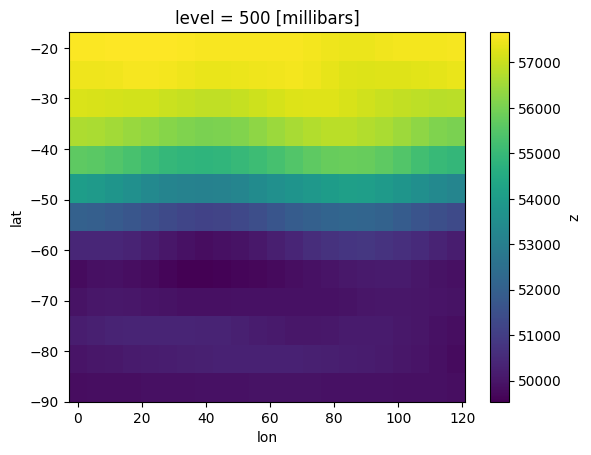

In [6]:
z500_train.mean(dim='time').plot()

## Defining the Kernel

We use a separable kernel in space and time:
$$K(\theta, \phi,t) = K_{\text{space}}(\theta, \phi) \times K_{\text{time}}(t),$$
where $K_{\text{space}}(\theta, \phi) = \sum_n K_{n\text{, Matern}}(\theta, \phi)$ and $K_{\text{time}}(t) = \sum_n K_{n\text{, Periodic}}(t)$.

In [7]:
# Define the GP regression kernel, separable in space and time
### First define the spatial kernel 
spatial_lengths = [0.08, 0.25, 0.5]

# Smoothness param of matern kernel set to 3/2
matern_spatial_1 = SphericalMaternKernel(nu=1.5, active_dims=[0,1]).to(device)
matern_spatial_1.lengthscale = torch.tensor(spatial_lengths[0]).to(device)
matern_spatial_2 = SphericalMaternKernel(nu=1.5, active_dims=[0,1]).to(device)
matern_spatial_2.lengthscale = torch.tensor(spatial_lengths[1]).to(device)
matern_spatial_3 = SphericalMaternKernel(nu=1.5, active_dims=[0,1]).to(device)
matern_spatial_3.lengthscale = torch.tensor(spatial_lengths[2]).to(device)

spatial_kernel = matern_spatial_1 + matern_spatial_2 + matern_spatial_3

In [8]:
### For temporal kernel
# period_lengths = [24, 24*30*3, 24*30*12]
period = 24

time_kernel1 = gpytorch.kernels.PeriodicKernel(active_dims=[2]).to(device) # Daily    
time_kernel1.period_length = torch.tensor(period).to(device)
#time_kernel1 = gpytorch.kernels.PeriodicKernel(active_dims=[2]).to(device) # Daily    
#time_kernel1.period_length = torch.tensor(period_lengths[0]).to(device)
#time_kernel2 = gpytorch.kernels.PeriodicKernel(active_dims=[2]).to(device) 
#time_kernel2.period_length = torch.tensor(period_lengths[1]).to(device)
#time_kernel3 = gpytorch.kernels.PeriodicKernel(active_dims=[2]).to(device) 
#time_kernel3.period_length = torch.tensor(period_lengths[2]).to(device)

#time_kernel1.register_prior("period_length_prior", gpytorch.priors.NormalPrior(period_lengths[0], period_lengths[0]/3), "period_length")
#time_kernel2.register_prior("period_length_prior", gpytorch.priors.NormalPrior(period_lengths[1], period_lengths[1]/3), "period_length")

matern_time_1 = gpytorch.kernels.MaternKernel(nu=1.5, active_dims=[2]).to(device)
#matern_time_1.lengthscale = torch.tensor(40).to(device)
#matern_time_2 = gpytorch.kernels.MaternKernel(nu=1.5, active_dims=[2]).to(device)
#matern_time_2.lengthscale = torch.tensor(24*7).to(device)

time_kernel = matern_time_1 + time_kernel1
#time_kernel = matern_time_1 + time_kernel1 + time_kernel2 + time_kernel3

In [9]:
# Assembling the Kernel

# If wrap scaling only to the spatial kernel
# spatial_kernel = gpytorch.kernels.ScaleKernel(spatial_kernel).to(device)
# kernel = spatial_kernel * time_kernel

# If wrap scaling to the whole kernel
kernel = gpytorch.kernels.ScaleKernel(spatial_kernel * time_kernel).to(device)

## Training and Evaluation

In [12]:
def train_gp(lead_time_h, data_train, data_test, space_subsample=1, time_subsample=1, frac=0.01, epochs=5000, save_model=False, device=device):
    """
    Train a Gaussian Process model using GPyTorch. Can add subsampling the data for efficiency.
    """
    
    # Prepare training data
    X_train, Y_train = create_latlon_data(data_train, data_test, lead_time_h, space_subsample=space_subsample, 
                                                  time_subsample=time_subsample)
    X_train = X_train.to(device)
    Y_train = Y_train.to(device)

    # Random Sampling (should set space and time subsampling be 1 if using random sampling)
    N = X_train.shape[0] * X_train.shape[1] * X_train.shape[2] 
    # n_frac = int(frac * N) # Fraction of points to be chosen
    n_frac = 15000
    X_train = X_train.view(-1, 3)
    indices = torch.randperm(X_train.size(0))[:n_frac]
    X_train = X_train[indices] 
    Y_train = Y_train[indices]

    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
    model = ExactGP(X_train, Y_train, likelihood, kernel).to(device)
    
    # Train model
    model.train()
    likelihood.train()

    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005) 
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.965)

    # Loss fn
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    # Training loop
    print("Starting Exact GP regression training on a single month:")
    # Reset the peak memory statistics before training
    torch.cuda.reset_peak_memory_stats(device)
    start_time = time.time()

    hyperparams_track = []
    with tqdm(total=epochs, desc="Training Progress", unit="epoch") as pbar:
        for i in range(epochs):
            optimizer.zero_grad()
            output = model(X_train)
            loss_val = -mll(output, Y_train)
            loss_val.backward()
            optimizer.step() 
            scheduler.step()
            pbar.set_postfix(loss=f"{loss_val.item():.3f}")
            pbar.update(1)

            # Record model params
            spatial_kernel = model.covar_module.base_kernel.kernels[0]
            temporal_kernel = model.covar_module.base_kernel.kernels[1]
            hyperparams_track.append({
                "loss": loss_val.item(),
                "rmse": torch.sqrt(torch.mean((output.mean - Y_train)**2)).item(),
                "mean": model.mean_module.constant.item(),
                "noise": likelihood.noise.item(),
                "outputscale": model.covar_module.outputscale.item(),
                "spatial_1_lengthscale": spatial_kernel.kernels[0].lengthscale.item(),
                "spatial_2_lengthscale": spatial_kernel.kernels[1].lengthscale.item(),
                "spatial_3_lengthscale": spatial_kernel.kernels[2].lengthscale.item(),
                "time_matern_lengthscale": temporal_kernel.kernels[0].lengthscale.item(),
                "time_lengthscale_1": temporal_kernel.kernels[1].lengthscale.item(),
                "time_period_1": temporal_kernel.kernels[1].period_length.item(),
                #"time_lengthscale_2": temporal_kernel.kernels[2].lengthscale.item(),
                #"time_period_2": temporal_kernel.kernels[2].period_length.item(),
                #"time_lengthscale_3": temporal_kernel.kernels[3].lengthscale.item(),
                #"time_period_3": temporal_kernel.kernels[3].period_length.item(),
            })            

    current_allocated = torch.cuda.memory_allocated(device)
    max_allocated = torch.cuda.max_memory_allocated(device)
    print(f"Current GPU memory allocated: {current_allocated / (1024**2):.2f} MB")
    print(f"Peak GPU memory allocated: {max_allocated / (1024**2):.2f} MB")

    end_time = time.time()
    print("Training completed")
    time_elapsed = end_time - start_time
    print(f"Training time: {time_elapsed:.2f}s")

    # Save model
    if save_model:
        torch.save(model.state_dict(), "STGP-weather-forecasting/saved_models/gp_model.pth")
        torch.save(likelihood.state_dict(), "STGP-weather-forecasting/saved_models/gp_likelihood.pth")
        print("Saved model")

    return model, likelihood, hyperparams_track, X_train, Y_train

In [13]:
lead_time = 24 # 3-day forecasting
space_subsample = 1 # Set 1 if using random subsampling
time_subsample = 6 
frac = 0.05 # Fraction of points to be picked from the full training set
# Train GP model
model, likelihood, hyperparams_track, X_train, Y_train = train_gp(lead_time, data_train, data_test, space_subsample, time_subsample, frac=frac)

Processing Training Dataset
Combined coords info --> Shape: torch.Size([120, 13, 22, 3]), Mem: 0.79 MB
Target info --> Shape: torch.Size([34320]), Mem: 0.13 MB
Starting Exact GP regression training on a single month:


Training Progress:   0%|          | 0/5000 [00:00<?, ?epoch/s]

Current GPU memory allocated: 1738.24 MB
Peak GPU memory allocated: 39505.23 MB
Training completed
Training time: 2100.75s


In [14]:
X_test, Y_test, lat, lon = create_latlon_data(data_train, data_test, lead_time, space_subsample=1, 
                                                time_subsample=6, train=False)
X_test = X_test.to(device)
Y_test = Y_test.to(device)
X_test = X_test.view(-1,3)
nlat = len(lat)
nlon = len(lon)

# Make Predictions
model.eval()
likelihood.eval()
with torch.no_grad():
    pred_dist = model(X_test)
    Y_pred = pred_dist.mean
    Y_std = pred_dist.stddev  
    mse = torch.mean((Y_pred - Y_test)**2)
    rmse = torch.sqrt(mse)
    print("MSE: ", mse.item())
    print("RMSE: ", rmse.item())

    #Y_pred_actual = (Y_pred.detach().cpu().numpy() * data_std.values + data_mean.values).reshape(-1,nlat,nlon) + seasonal_forecast.isel(time=slice(lead_time, None, time_subsample)).values
    #Y_test_actual = (Y_test.detach().cpu().numpy() * data_std.values + data_mean.values).reshape(-1,nlat,nlon) + seasonal_forecast.isel(time=slice(lead_time, None, time_subsample)).values
    Y_pred_actual = (Y_pred.detach().cpu().numpy() * data_std.values + data_mean.values).reshape(-1,nlat,nlon)
    Y_test_actual = (Y_test.detach().cpu().numpy() * data_std.values + data_mean.values).reshape(-1,nlat,nlon)
    err = Y_pred_actual - Y_test_actual
    weights_lat = np.cos(np.deg2rad(lat))
    weights_lat /= weights_lat.mean()
    wrmse = np.sqrt((err**2 * weights_lat[None, :, None]).mean())
    print("Weighted RMSE: ", wrmse)

Y_pred = Y_pred.detach().cpu().numpy()  
Y_test = Y_test.detach().cpu().numpy()  
Y_std = Y_std.detach().cpu().numpy()

Processing Test Dataset
Combined coords info --> Shape: torch.Size([28, 13, 22, 3]), Mem: 0.18 MB
Target info --> Shape: torch.Size([8008]), Mem: 0.03 MB
MSE:  0.08387022227826761
RMSE:  0.28960356054141945
Weighted RMSE:  834.6372772234139


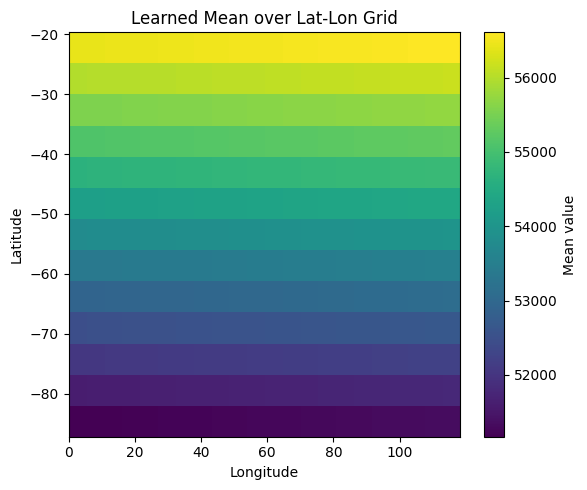

In [15]:
Lon, Lat = np.meshgrid(data_train.lon.values, data_train.lat.values)
coords = np.column_stack([Lat.ravel(), Lon.ravel()])
coords_tensor = torch.from_numpy(coords.astype(np.float32)).to(next(model.mean_module.parameters()).device)

with torch.no_grad():
    mean_vals = model.mean_module(coords_tensor).cpu().numpy()

mean_grid = mean_vals.reshape(len(lat), len(lon)) * data_std.values + data_mean.values

# 2) Plot with imshow for a clean heatmap:
plt.figure(figsize=(6,5))
plt.imshow(
    mean_grid,
    origin='lower',                        
    extent=[data_train.lon.values.min(), data_train.lon.values.max(), data_train.lat.values.min(), data_train.lat.values.max()],
    aspect='auto'
)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Learned Mean over Lat-Lon Grid')
plt.colorbar(label='Mean value')
plt.tight_layout()
plt.show()

## Performance Plots 

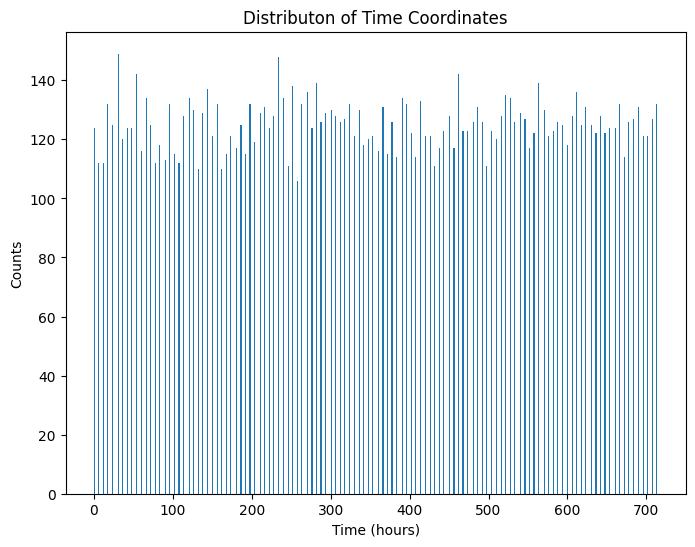

In [16]:
rand_coords = X_train[:,:2].detach().cpu().numpy()
rand_time = X_train[:,2].detach().cpu().numpy()

plt.figure(figsize=(8,6))
plt.hist(rand_time, bins=500)
plt.xlabel('Time (hours)')
plt.ylabel('Counts')
plt.title('Distributon of Time Coordinates')
plt.show()

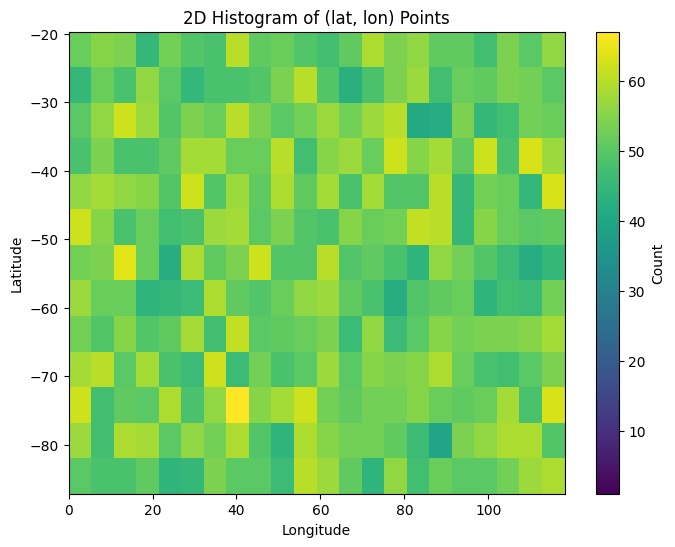

In [17]:
lat = X_train[:, 0].detach().cpu().numpy()
lon = X_train[:, 1].detach().cpu().numpy()

nlat = len(set(lat))
nlon = len(set(lon))

cmap = plt.get_cmap('viridis').copy()
cmap.set_under('white')

plt.figure(figsize=(8,6))
plt.hist2d(lon, lat, bins=[nlon, nlat], cmap=cmap, vmin=1) # highlights bin with 0 counts as red
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('2D Histogram of (lat, lon) Points')
plt.colorbar(label='Count')
plt.show()

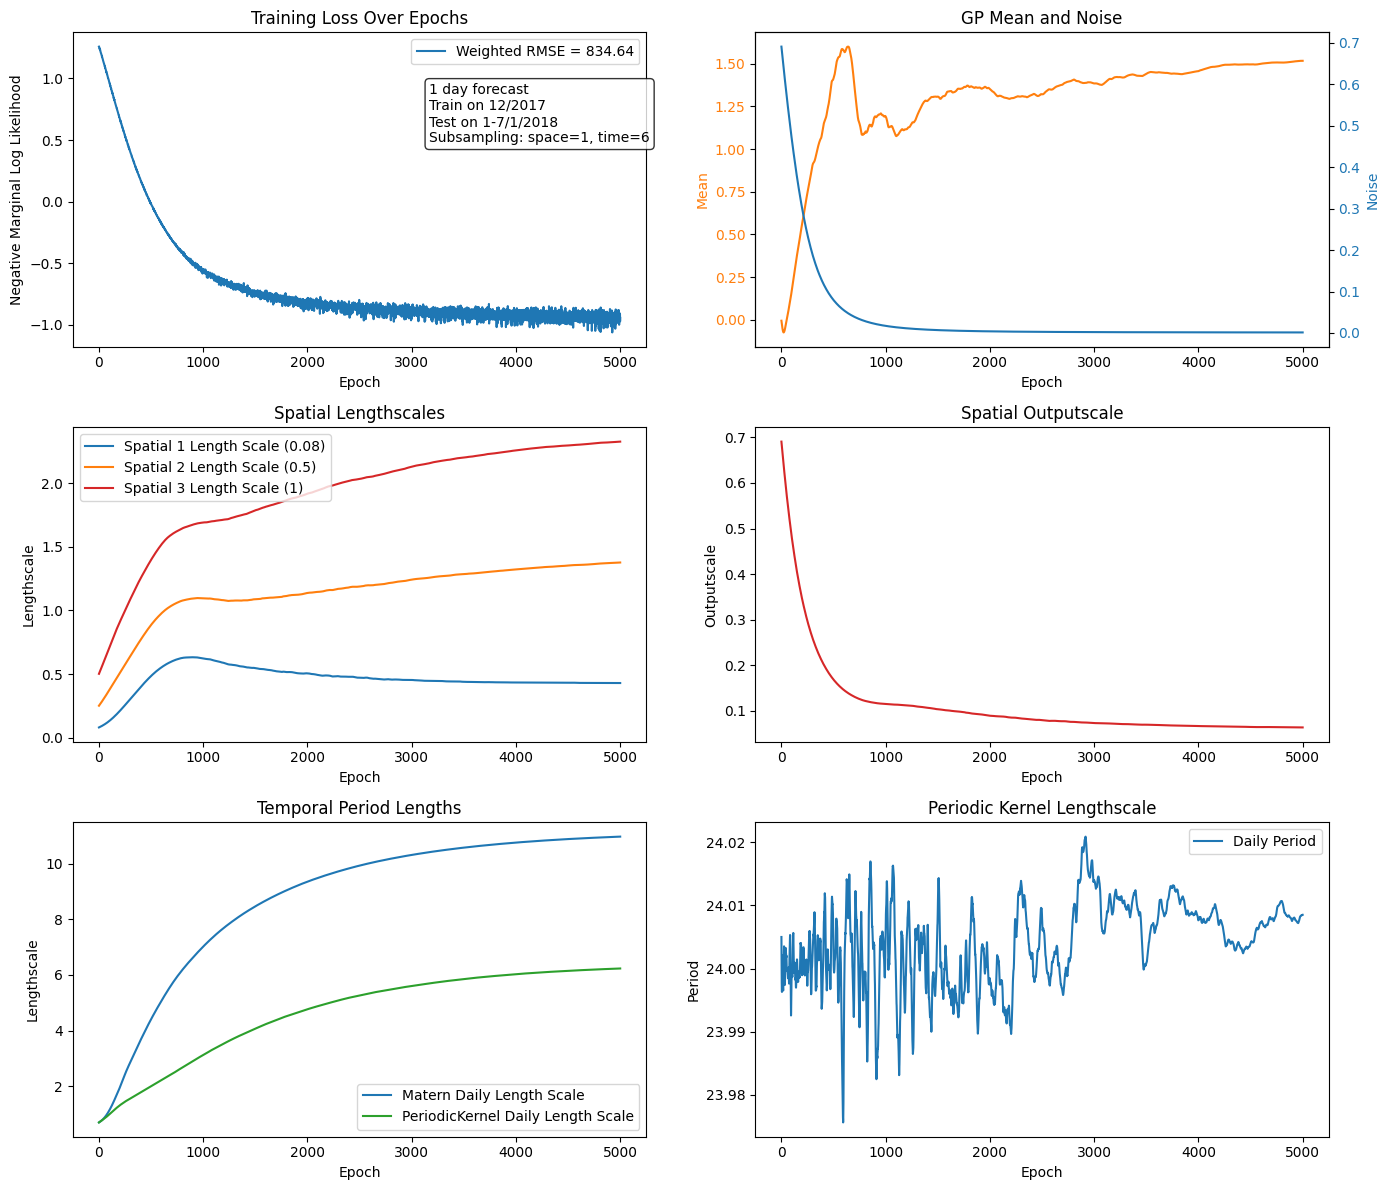

In [18]:
# Convert your tracking list into a DataFrame
df = pd.DataFrame(hyperparams_track)
epochs_range = np.arange(len(df))

# Create a figure with 3 rows and 2 columns of subplots
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))

# --- Row 1 ---
# Left: Loss
axs[0, 0].plot(epochs_range, df["loss"], label=f'Weighted RMSE = {wrmse:.2f}', color='tab:blue')
axs[0, 0].set_title("Training Loss Over Epochs")
axs[0, 0].set_xlabel("Epoch")
axs[0, 0].set_ylabel("Negative Marginal Log Likelihood")
axs[0, 0].legend()

axs[0, 0].text(
    0.6215, 0.65, 
    f"1 day forecast\nTrain on 12/2017\nTest on 1-7/1/2018\nSubsampling: space={space_subsample}, time={time_subsample}",
    transform=axs[0, 0].transAxes,  # interpret (x, y) as axes-relative
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8, boxstyle='round')
)

# Right: Mean and Noise
axs[0, 1].plot(epochs_range, df["mean"], color='tab:orange', label="Mean")
axs[0, 1].set_title("GP Mean and Noise")
axs[0, 1].set_xlabel("Epoch")
axs[0, 1].set_ylabel("Mean", color='tab:orange')
axs[0, 1].tick_params(axis='y', labelcolor='tab:orange')
ax_noise = axs[0, 1].twinx()
ax_noise.plot(epochs_range, df["noise"], color='tab:blue', label="Noise")
ax_noise.set_ylabel("Noise", color='tab:blue')
ax_noise.tick_params(axis='y', labelcolor='tab:blue')

# --- Row 2 ---
# Left: Spatial lengthscales
axs[1, 0].plot(epochs_range, df["spatial_1_lengthscale"], label='Spatial 1 Length Scale (0.08)', color='tab:blue')
axs[1, 0].plot(epochs_range, df["spatial_2_lengthscale"], label='Spatial 2 Length Scale (0.5)', color='tab:orange')
axs[1, 0].plot(epochs_range, df["spatial_3_lengthscale"], label='Spatial 3 Length Scale (1)' , color='tab:red')
axs[1, 0].set_title("Spatial Lengthscales")
axs[1, 0].set_xlabel("Epoch")
axs[1, 0].set_ylabel("Lengthscale")
axs[1, 0].legend()

# Right: Spatial outputscale
# axs[1, 1].plot(epochs_range, df["spatial_outputscale"], label='Output scale from ScaleKernel', color='tab:red')
axs[1, 1].plot(epochs_range, df["outputscale"], label='Output scale from ScaleKernel', color='tab:red')
axs[1, 1].set_title("Spatial Outputscale")
axs[1, 1].set_xlabel("Epoch")
axs[1, 1].set_ylabel("Outputscale")

# --- Row 3 ---
# Left: Temporal lengthscales
axs[2, 0].plot(epochs_range, df["time_matern_lengthscale"], label='Matern Daily Length Scale', color='tab:blue')
axs[2, 0].plot(epochs_range, df["time_lengthscale_1"], label='PeriodicKernel Daily Length Scale', color='tab:green')
#axs[2, 0].plot(epochs_range, df["time_period_weekly"], label='PeriodicKernel Weekly Length Scale', color='tab:orange')
axs[2, 0].set_title("Temporal Period Lengths")
axs[2, 0].set_xlabel("Epoch")
axs[2, 0].set_ylabel("Lengthscale")
axs[2, 0].legend()

# Right: Temporal periods
axs[2, 1].plot(epochs_range, df["time_period_1"], label='Daily Period', color='tab:blue')
# axs[2, 1].plot(epochs_range, df["time_period_three_days"], label='3-Day Period', color='tab:orange')
#axs[2, 1].plot(epochs_range, df["time_lengthscale_weekly"], label='Weekly Period', color='tab:red')
axs[2, 1].set_title("Periodic Kernel Lengthscale")
axs[2, 1].set_xlabel("Epoch")
axs[2, 1].set_ylabel("Period")
axs[2, 1].legend()

plt.tight_layout()
plt.show()

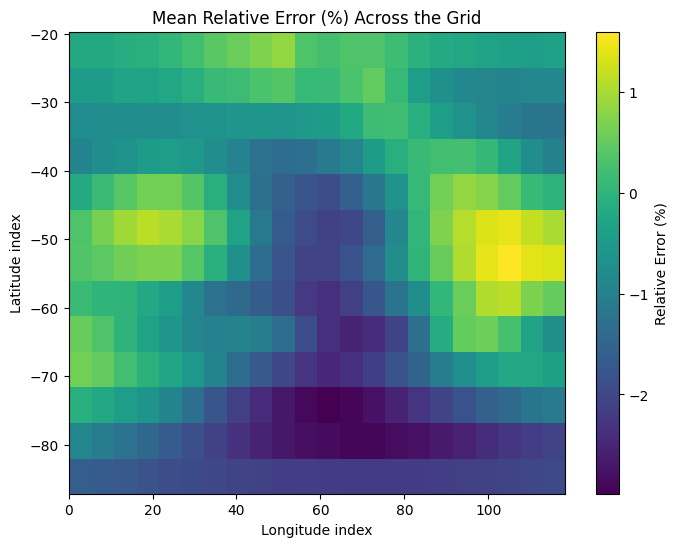

In [19]:
relative_error = (Y_pred_actual - Y_test_actual) / Y_test_actual * 100  # shape (ntime, 7, 13)
relative_error_mean = relative_error.mean(axis=0)  # shape (7, 13)

plt.figure(figsize=(8, 6))
im = plt.imshow(relative_error_mean, aspect='auto',
                extent=[lon.min(), lon.max(), lat.min(), lat.max()],
                origin='lower')
plt.title('Mean Relative Error (%) Across the Grid')
plt.xlabel('Longitude index')
plt.ylabel('Latitude index')
plt.colorbar(im, label='Relative Error (%)')
plt.show()

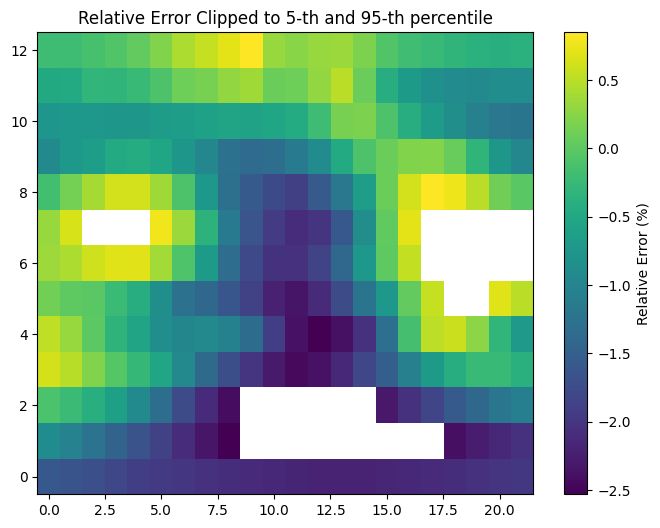

In [20]:
low_q = np.percentile(relative_error_mean, 5)
high_q = np.percentile(relative_error_mean, 95)
masked_error = np.ma.masked_outside(relative_error_mean, low_q, high_q)

plt.figure(figsize=(8, 6))
im = plt.imshow(masked_error, aspect='auto', origin='lower')
plt.colorbar(im, label='Relative Error (%)')
plt.title('Relative Error Clipped to 5-th and 95-th percentile')
plt.show()

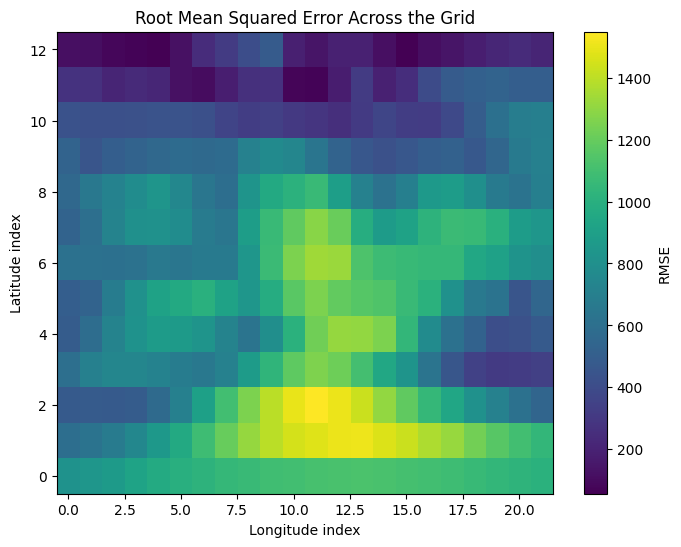

In [21]:
rmse_error = np.sqrt((Y_pred_actual - Y_test_actual)**2)
rmse_error_mean = rmse_error.mean(axis=0)  # shape (7, 13)

plt.figure(figsize=(8, 6))
im = plt.imshow(rmse_error_mean, aspect='auto', origin='lower')
plt.title('Root Mean Squared Error Across the Grid')
plt.xlabel('Longitude index')
plt.ylabel('Latitude index')
plt.colorbar(im, label='RMSE')
plt.show()

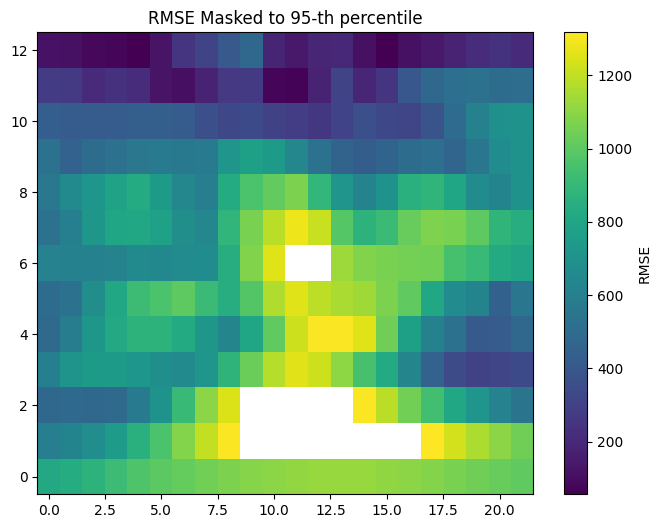

In [22]:
low_q_rmse = np.percentile(rmse_error_mean, 0)
high_q_rmse = np.percentile(rmse_error_mean, 95)
masked_error_rmse = np.ma.masked_outside(rmse_error_mean, low_q_rmse, high_q_rmse)

plt.figure(figsize=(8, 6))
im = plt.imshow(masked_error_rmse, aspect='auto', origin='lower')
plt.colorbar(im, label='RMSE')
plt.title('RMSE Masked to 95-th percentile')
plt.show()

In [23]:
max_idx = np.argmax(relative_error_mean)
min_idx = np.argmin(relative_error_mean)
best_idx = np.argmin(np.abs(relative_error_mean))

flat_max_idx = np.unravel_index(max_idx, relative_error_mean.shape)
flat_min_idx = np.unravel_index(min_idx, relative_error_mean.shape)
flat_best_idx = np.unravel_index(best_idx, relative_error_mean.shape)

max_err = relative_error_mean[flat_max_idx[0],flat_max_idx[1]]
min_err = relative_error_mean[flat_min_idx[0],flat_min_idx[1]]
best_err = relative_error_mean[flat_best_idx[0],flat_best_idx[1]]

print(f"Highest relative error: ({int(flat_max_idx[0])},{int(flat_max_idx[1])}), with relative error in percentage: {max_err:.3f}")
print(f"Lowest relative error: ({int(flat_min_idx[0])},{int(flat_min_idx[1])}), with relative error in percentage: {min_err:.3f}")
print(f"Smallest relative error: ({int(flat_best_idx[0])},{int(flat_best_idx[1])}), with relative error in percentage: {best_err:.3f}")

Highest relative error: (6,19), with relative error in percentage: 1.593
Lowest relative error: (2,11), with relative error in percentage: -2.983
Smallest relative error: (4,2), with relative error in percentage: -0.002


In [24]:
# Best and worst location based on rmse
rmse_max_idx = np.argmax(rmse_error_mean)
rmse_min_idx = np.argmin(rmse_error_mean)

flat_rmse_max_idx = np.unravel_index(rmse_max_idx, rmse_error_mean.shape)
flat_rmse_min_idx = np.unravel_index(rmse_min_idx, rmse_error_mean.shape)

rmse_max_err = rmse_error_mean[flat_rmse_max_idx[0],flat_rmse_max_idx[1]]
rmse_min_err = rmse_error_mean[flat_rmse_min_idx[0],flat_rmse_min_idx[1]]

print(f"Highest RMSE: ({int(flat_rmse_max_idx[0])},{int(flat_rmse_max_idx[1])}), with value: {rmse_max_err:.3f}")
print(f"Lowest RMSE: ({int(flat_rmse_min_idx[0])},{int(flat_rmse_min_idx[1])}), with value: {rmse_min_err:.3f}")

Highest RMSE: (2,11), with value: 1548.793
Lowest RMSE: (12,15), with value: 56.220


## Observing how the individual point performs

In [25]:
model.eval()
likelihood.eval()
with torch.no_grad():
    pred_train = model(X_train)
    train_mean = pred_train.mean  
    train_std = pred_train.stddev  

sorted_idx = torch.argsort(X_train[:,2])

train_mean = train_mean[sorted_idx].detach().cpu().numpy()
train_std = train_std[sorted_idx].detach().cpu().numpy()
Y_train = Y_train[sorted_idx].detach().cpu().numpy()

/home/syw24/miniforge3/envs/hartree/lib/python3.12/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


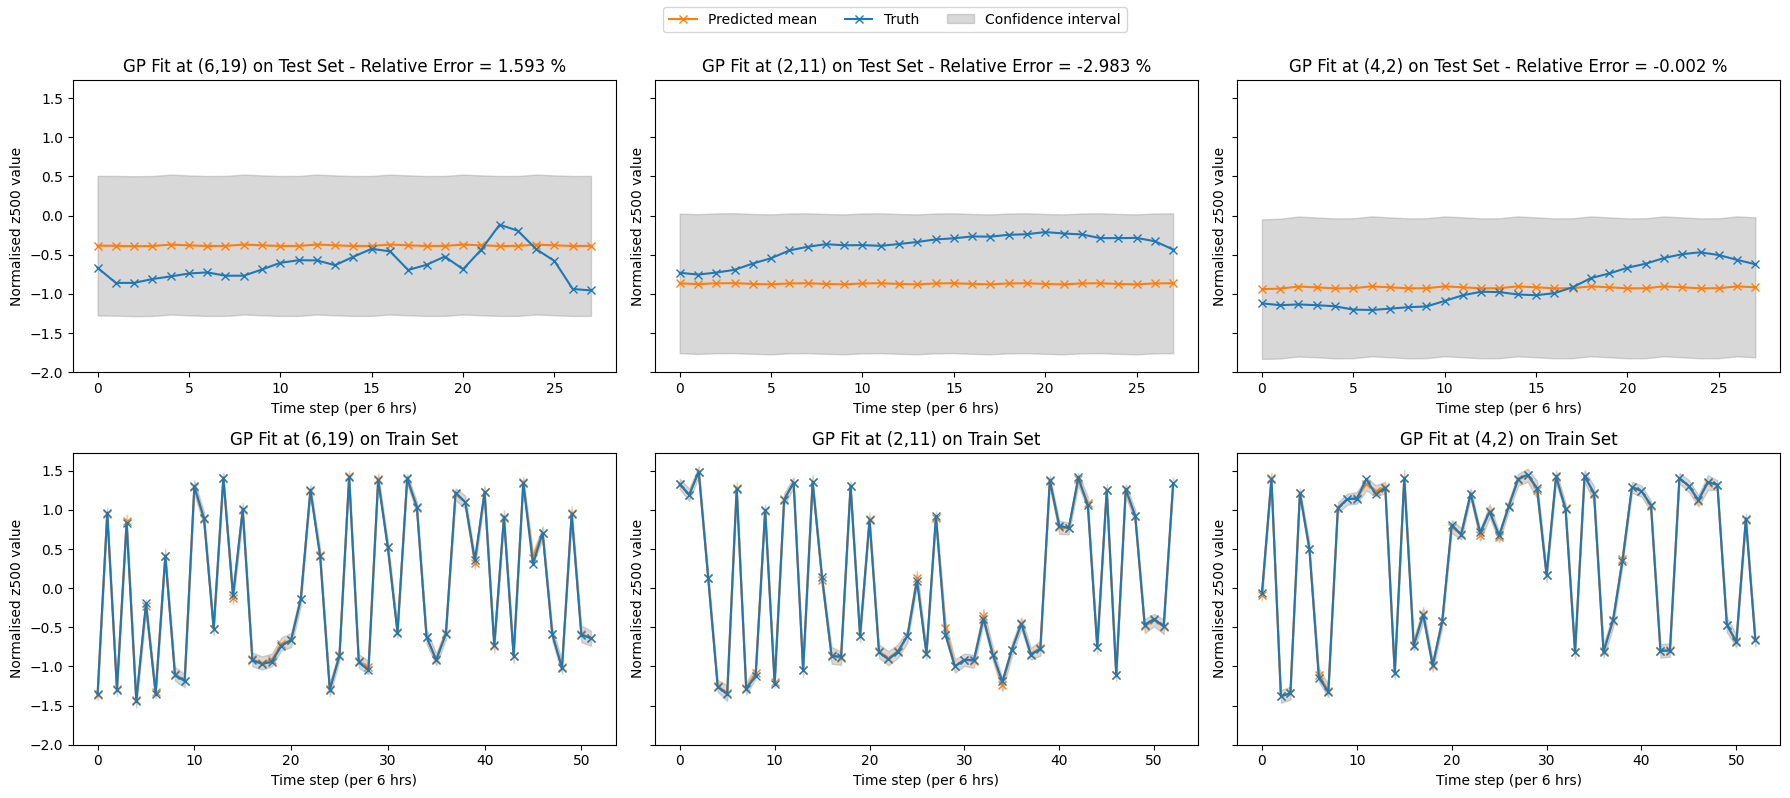

In [26]:
# Create a 2x3 figure
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=True)

idx = [max_idx, min_idx, best_idx]
val = [max_err, min_err, best_err]

for i, p_idx in enumerate(idx):
    flat_idx = np.unravel_index(p_idx, relative_error_mean.shape)
    ax = axes[0, i]  

    pred_vals = Y_pred.reshape(-1)[p_idx::(nlat*nlon)]
    truth_vals = Y_test.reshape(-1)[p_idx::(nlat*nlon)]
    std_vals = Y_std.reshape(-1)[p_idx::(nlat*nlon)]

    ax.plot(pred_vals, marker='x', label='Predicted mean', color='tab:orange')
    ax.plot(truth_vals, marker='x', label='Truth', color='tab:blue')
    ax.fill_between(np.arange(len(pred_vals)),
                    pred_vals - 2 * std_vals,
                    pred_vals + 2 * std_vals,
                    alpha=0.3, color='tab:gray', label='Confidence interval')
    ax.set_xlabel(f"Time step (per {time_subsample} hrs)")
    ax.set_ylabel("Normalised z500 value")
    ax.set_title(f"GP Fit at ({int(flat_idx[0])},{int(flat_idx[1])}) on Test Set - Relative Error = {val[i]:.3f} %")

for i, p_idx in enumerate(idx):
    flat_idx = np.unravel_index(p_idx, relative_error_mean.shape)
    ax = axes[1, i]  

    pred_vals = train_mean.reshape(-1)[p_idx::(nlat*nlon)]
    truth_vals = Y_train.reshape(-1)[p_idx::(nlat*nlon)]
    std_vals = train_std.reshape(-1)[p_idx::(nlat*nlon)]

    ax.plot(pred_vals, marker='x', label='Predicted mean', color='tab:orange')
    ax.plot(truth_vals, marker='x', label='Truth', color='tab:blue')
    ax.fill_between(np.arange(len(pred_vals)),
                    pred_vals - 2 * std_vals,
                    pred_vals + 2 * std_vals,
                    alpha=0.3, color='tab:gray', label='Confidence interval')
    ax.set_xlabel(f"Time step (per {time_subsample} hrs)")
    ax.set_ylabel("Normalised z500 value")
    ax.set_title(f"GP Fit at ({int(flat_idx[0])},{int(flat_idx[1])}) on Train Set")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.95]) 
plt.show()

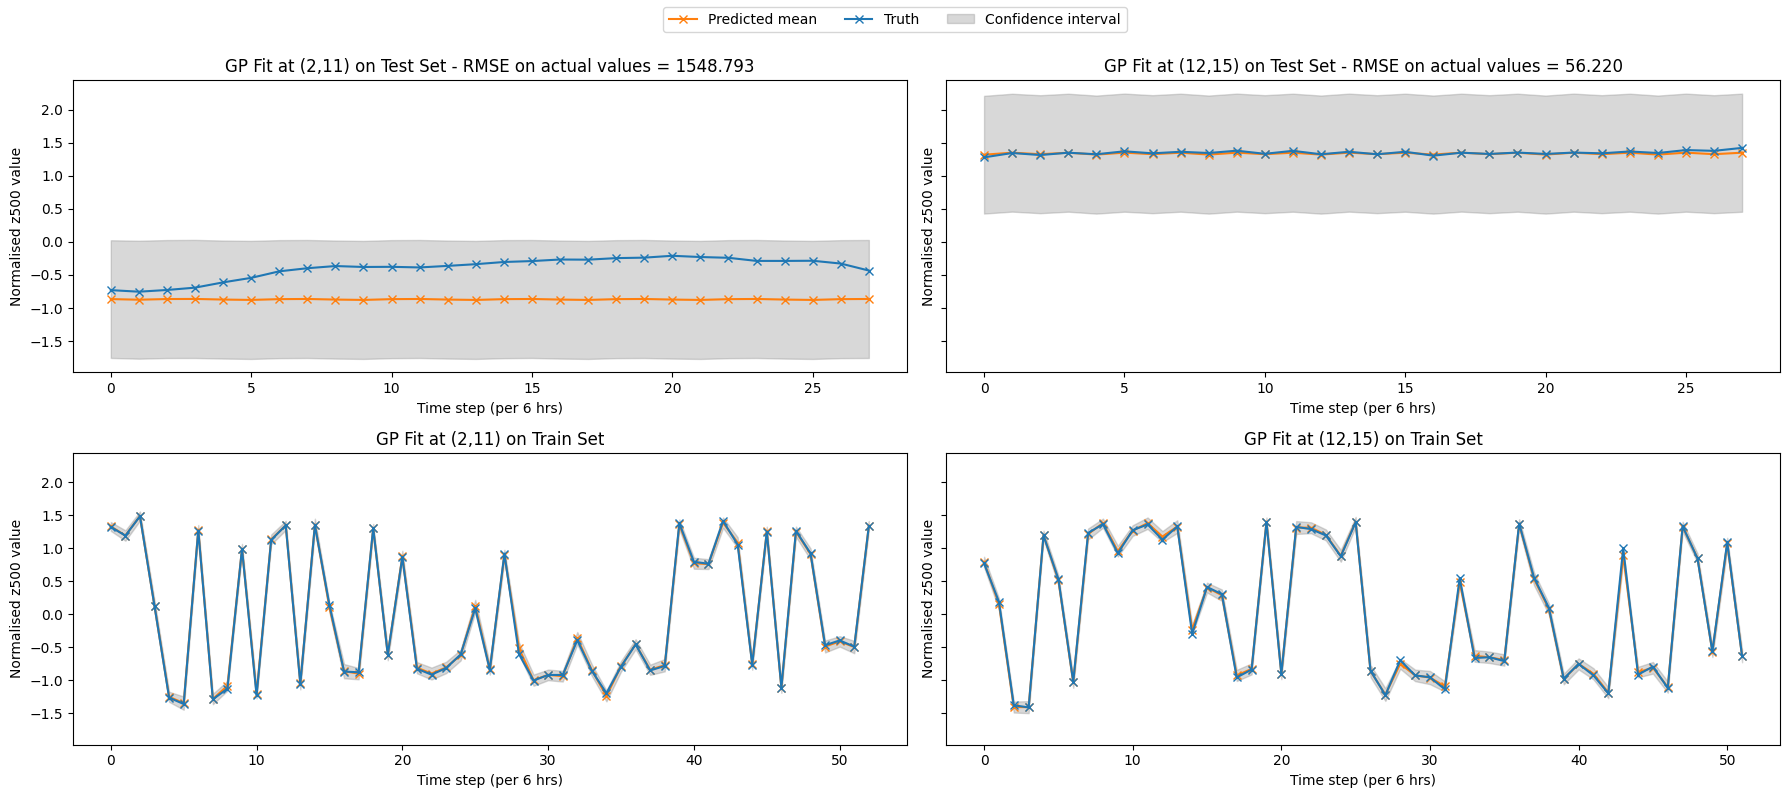

In [27]:
# Create a 2x3 figure
fig, axes = plt.subplots(2, 2, figsize=(18, 8), sharex=False, sharey=True)

idx = [rmse_max_idx, rmse_min_idx]
val = [rmse_max_err, rmse_min_err]

for i, p_idx in enumerate(idx):
    flat_idx = np.unravel_index(p_idx, rmse_error_mean.shape)
    ax = axes[0, i]  

    pred_vals = Y_pred.reshape(-1)[p_idx::(nlat*nlon)]
    truth_vals = Y_test.reshape(-1)[p_idx::(nlat*nlon)]
    std_vals = Y_std.reshape(-1)[p_idx::(nlat*nlon)]

    ax.plot(pred_vals, marker='x', label='Predicted mean', color='tab:orange')
    ax.plot(truth_vals, marker='x', label='Truth', color='tab:blue')
    ax.fill_between(np.arange(len(pred_vals)),
                    pred_vals - 2 * std_vals,
                    pred_vals + 2 * std_vals,
                    alpha=0.3, color='tab:gray', label='Confidence interval')
    ax.set_xlabel(f"Time step (per {time_subsample} hrs)")
    ax.set_ylabel("Normalised z500 value")
    ax.set_title(f"GP Fit at ({int(flat_idx[0])},{int(flat_idx[1])}) on Test Set - RMSE on actual values = {val[i]:.3f}")

for i, p_idx in enumerate(idx):
    flat_idx = np.unravel_index(p_idx, rmse_error_mean.shape)
    ax = axes[1, i]  

    pred_vals = train_mean.reshape(-1)[p_idx::(nlat*nlon)]
    truth_vals = Y_train.reshape(-1)[p_idx::(nlat*nlon)]
    std_vals = train_std.reshape(-1)[p_idx::(nlat*nlon)]

    ax.plot(pred_vals, marker='x', label='Predicted mean', color='tab:orange')
    ax.plot(truth_vals, marker='x', label='Truth', color='tab:blue')
    ax.fill_between(np.arange(len(pred_vals)),
                    pred_vals - 2 * std_vals,
                    pred_vals + 2 * std_vals,
                    alpha=0.3, color='tab:gray', label='Confidence interval')
    ax.set_xlabel(f"Time step (per {time_subsample} hrs)")
    ax.set_ylabel("Normalised z500 value")
    ax.set_title(f"GP Fit at ({int(flat_idx[0])},{int(flat_idx[1])}) on Train Set")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.95]) 
plt.show()